In [22]:
import pandas as pd
df=pd.read_csv(r"D:\Preventive maintanence\data\raw\ai4i2020.csv")
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [23]:
df["Temperature_Difference"] = (
    df["Process temperature [K]"]
    -
    df["Air temperature [K]"]
)

print(df["Temperature_Difference"])

0       10.5
1       10.5
2       10.4
3       10.4
4       10.5
        ... 
9995     9.6
9996     9.5
9997     9.6
9998     9.7
9999     9.7
Name: Temperature_Difference, Length: 10000, dtype: float64


In [24]:
df["Mechanical_Stress"] = (
    df["Rotational speed [rpm]"]
    *
    df["Torque [Nm]"]
)

print(df["Mechanical_Stress"])

0       66382.8
1       65190.4
2       74001.2
3       56603.5
4       56320.0
         ...   
9995    47318.0
9996    51897.6
9997    54943.0
9998    68288.0
9999    60300.0
Name: Mechanical_Stress, Length: 10000, dtype: float64


In [25]:
# 4. Type Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Type_Encoded"] = encoder.fit_transform(df["Type"])

print(df["Type_Encoded"])

0       2
1       1
2       1
3       1
4       1
       ..
9995    2
9996    0
9997    2
9998    0
9999    2
Name: Type_Encoded, Length: 10000, dtype: int64


ANOTHER METHOD OF FEATURE ENGINEERING

In [26]:
type_dummies = pd.get_dummies(
    df["Type"],
    prefix="Type"
)

df = pd.concat(
    [df, type_dummies],
    axis=1
)

In [27]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temperature_Difference', 'Mechanical_Stress', 'Type_Encoded', 'Type_H', 'Type_L', 'Type_M']


In [28]:
df["Temperature_Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

df[["Air temperature [K]",
    "Process temperature [K]",
    "Temperature_Difference"]].head()

,Air temperature [K],Process temperature [K],Temperature_Difference
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [29]:
df["Mechanical_Stress"] = (
    df["Rotational speed [rpm]"] *
    df["Torque [Nm]"]
)

df[["Rotational speed [rpm]",
    "Torque [Nm]",
    "Mechanical_Stress"]].head()

,Rotational speed [rpm],Torque [Nm],Mechanical_Stress
0,1551,42.8,66382.8
1,1408,46.3,65190.4
2,1498,49.4,74001.2
3,1433,39.5,56603.5
4,1408,40.0,56320.0


In [30]:
df["Wear_Stress_Index"] = (
    df["Tool wear [min]"] *
    df["Torque [Nm]"]
)

df[["Tool wear [min]",
    "Torque [Nm]",
    "Wear_Stress_Index"]].head()

,Tool wear [min],Torque [Nm],Wear_Stress_Index
0,0,42.8,0.0
1,3,46.3,138.9
2,5,49.4,247.0
3,7,39.5,276.5
4,9,40.0,360.0


In [31]:
print(df["Type"].unique())

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Type_Encoded"] = le.fit_transform(df["Type"])

df[["Type", "Type_Encoded"]].head()

,Type,Type_Encoded
0,M,2
1,L,1
2,L,1
3,L,1
4,L,1


In [33]:
df.drop(
    columns=["UDI", "Product ID"],
    inplace=True
)

In [34]:
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temperature_Difference', 'Mechanical_Stress', 'Type_Encoded', 'Type_H',
       'Type_L', 'Type_M', 'Wear_Stress_Index'],
      dtype='str')


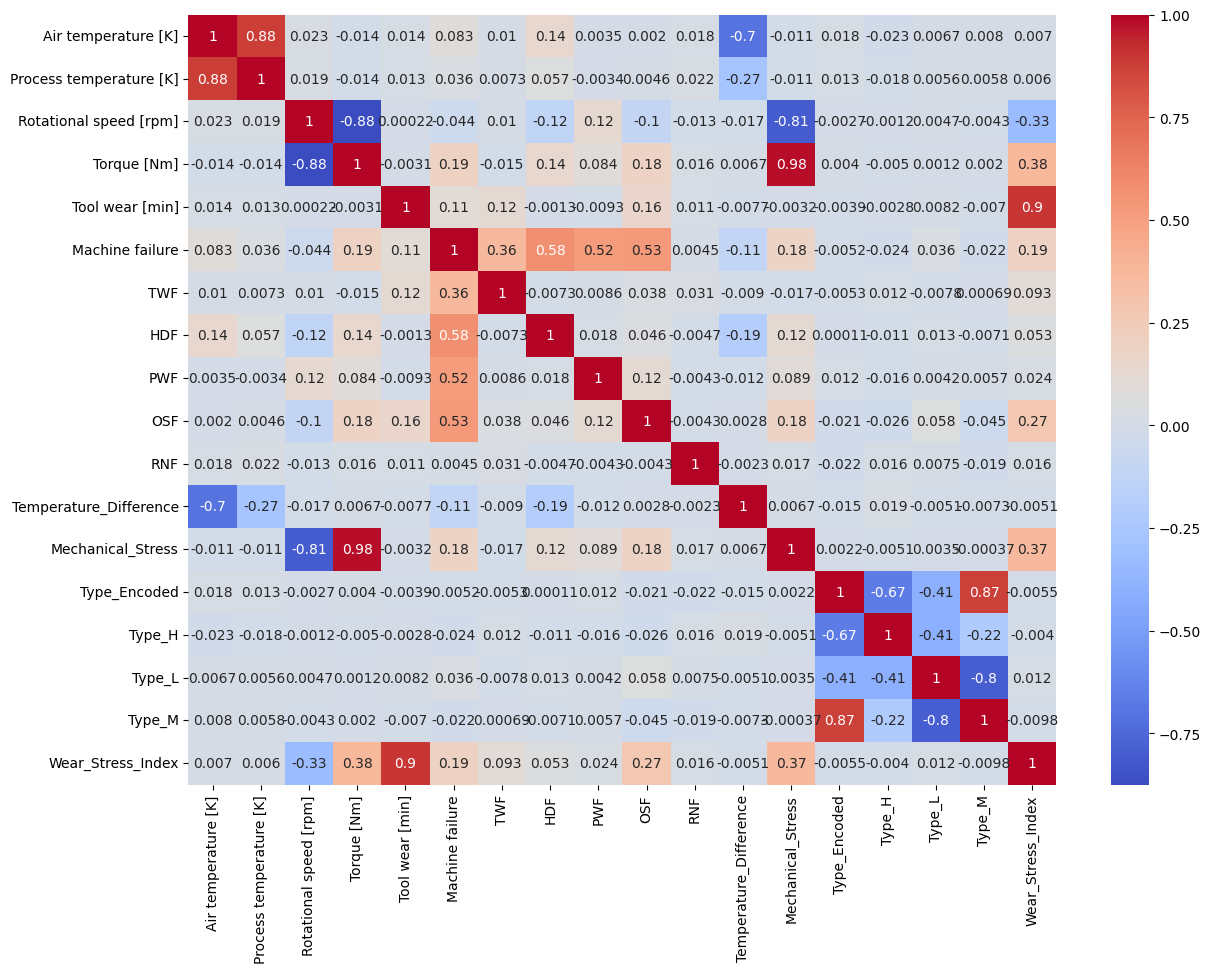

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [36]:
df.to_csv(
    "../data/processed/feature_engineered_ai4i2020.csv",
    index=False
)

print("Feature engineered dataset saved successfully")

Feature engineered dataset saved successfully
